# **Titanic Crisis Analysis — TCA**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [5]:
df['Title'] = df['Name'].str.extract(r', (\w+)\.', expand=False)

df['Age'] = df.groupby(['Sex', 'Pclass', 'Title']) ['Age'].transform(
    lambda x: x.fillna(x.median())
)

df['Age'] = df['Age'].fillna(df['Age'].median())

In [6]:
df["FamSize"] = df["SibSp"] + df["Parch"] + 1
df["FamSize"]
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamSize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,18.0,1,2,W./C. 6607,23.4500,NaN,S,Miss,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,1


In [7]:
df = df.drop(columns=["SibSp", "Parch"])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,Title,FamSize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,NaN,S,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C85,C,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,NaN,S,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,C123,S,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,NaN,S,Mr,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,211536,13.0000,NaN,S,Rev,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,112053,30.0000,B42,S,Miss,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,18.0,W./C. 6607,23.4500,NaN,S,Miss,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,111369,30.0000,C148,C,Mr,1


In [8]:
col = df.pop("FamSize")
df.insert(6,"FamSize",col)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,2,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,2,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,1,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,2,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,1,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,1,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,1,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,18.0,4,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,1,111369,30.0000,C148,C,Mr


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
FamSize          0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            1
dtype: int64

In [11]:
df.shape

(891, 12)

# Cabin Deck Feature

In [12]:
df['Cabin'] = df['Cabin'].fillna('U')

df['CabinDeck'] = df['Cabin'].str[0]

df = df.drop(columns=['Cabin'])

# Log(1 + Fare): to make fare skewness more normalized

In [13]:
df['FareLog'] = np.log1p(df['Fare'])

df = df.drop(columns=['Fare'])

<Axes: xlabel='FareLog', ylabel='Count'>

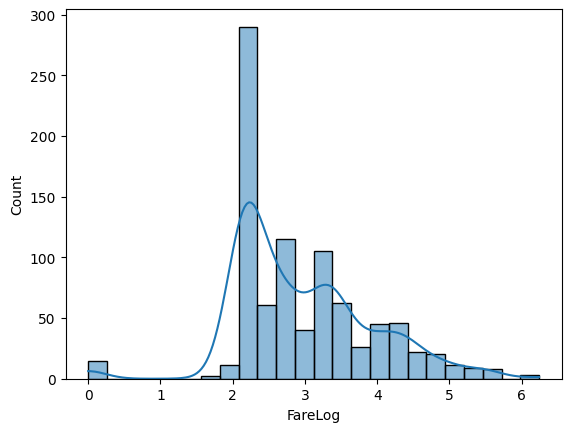

In [37]:
sns.histplot(df['FareLog'], kde=True)

# Gender & Survival Rates

In [14]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [15]:
df["Sex"][(df["Survived"] == 1) & (df["Sex"] == "male")].count()

np.int64(109)

## ~18.9% Survival rate in TCA

In [16]:
df["Sex"][(df["Survived"] == 1) & (df["Sex"] == "female")].count()

np.int64(233)

## ~74.2% Survival rate in TCA

In [17]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

# Age & Survival Rates

In [18]:
((df["Age"] > 0) & (df["Age"] < 12)).sum()

np.int64(72)

In [19]:
df["Survived"][(df["Age"] > 0) & (df["Age"] < 12)].sum()

np.int64(41)

In [20]:
((df["Age"] > 13) & (df["Age"] < 20)).sum()

np.int64(126)

In [21]:
df["Survived"][(df["Age"] > 13) & (df["Age"] < 20)].sum()

np.int64(56)

In [22]:
((df["Age"] > 21) & (df["Age"] < 40)).sum()

np.int64(458)

In [23]:
df["Survived"][(df["Age"] > 21) & (df["Age"] < 40)].sum()

np.int64(160)

In [24]:
((df["Age"] > 41) & (df["Age"] < 90)).sum()

np.int64(151)

In [25]:
df["Survived"][(df["Age"] > 41) & (df["Age"] < 90)].sum()

np.int64(61)

In [26]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [27]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [28]:
df.groupby(["Embarked", "Pclass"]).size()

Embarked  Pclass
C         1          85
          2          17
          3          66
Q         1           2
          2           3
          3          72
S         1         127
          2         164
          3         353
dtype: int64

# Passenger Class & Survival

In [29]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

# Name Extraction

In [30]:
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

df['Title'] = df['Title'].replace([
    'Lady', 'Countess', 'Capt', 'Col', 'Don',
    'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer',
    'Dona'
], 'Rare')

In [31]:
result = df.groupby(["Title", "Age"])["Survived"].mean()

print(result.to_string())

Title   Age  
Master  0.42     1.000000
        0.67     1.000000
        0.83     1.000000
        0.92     1.000000
        1.00     0.600000
        2.00     0.250000
        3.00     1.000000
        4.00     0.444444
        6.00     1.000000
        7.00     0.000000
        8.00     0.500000
        9.00     0.500000
        10.00    0.000000
        11.00    0.500000
        12.00    1.000000
Miss    0.75     1.000000
        1.00     1.000000
        2.00     0.333333
        3.00     0.500000
        4.00     1.000000
        5.00     1.000000
        6.00     0.500000
        7.00     1.000000
        8.00     0.500000
        9.00     0.000000
        10.00    0.000000
        11.00    0.000000
        13.00    1.000000
        14.00    0.666667
        14.50    0.000000
        15.00    1.000000
        16.00    0.833333
        17.00    0.750000
        18.00    0.581395
        19.00    1.000000
        20.00    0.000000
        21.00    0.571429
        22.00    0.77777

In [32]:
result = df.groupby(["Title", "Age"])["Survived"].mean()

print(result.to_string())

Title   Age  
Master  0.42     1.000000
        0.67     1.000000
        0.83     1.000000
        0.92     1.000000
        1.00     0.600000
        2.00     0.250000
        3.00     1.000000
        4.00     0.444444
        6.00     1.000000
        7.00     0.000000
        8.00     0.500000
        9.00     0.500000
        10.00    0.000000
        11.00    0.500000
        12.00    1.000000
Miss    0.75     1.000000
        1.00     1.000000
        2.00     0.333333
        3.00     0.500000
        4.00     1.000000
        5.00     1.000000
        6.00     0.500000
        7.00     1.000000
        8.00     0.500000
        9.00     0.000000
        10.00    0.000000
        11.00    0.000000
        13.00    1.000000
        14.00    0.666667
        14.50    0.000000
        15.00    1.000000
        16.00    0.833333
        17.00    0.750000
        18.00    0.581395
        19.00    1.000000
        20.00    0.000000
        21.00    0.571429
        22.00    0.77777

In [33]:
df.groupby("Title")["Survived"].value_counts()

Title   Survived
Master  1            23
        0            17
Miss    1           130
        0            55
Mr      0           436
        1            81
Mrs     1           100
        0            26
Rare    0            15
        1             7
Name: count, dtype: int64